<a href="https://colab.research.google.com/github/Amelbnmbh/HR-Analysis-at-HumanForYou/blob/main/Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

## Overview
In this section, we conduct exploratory data analysis (EDA) to detect trends, patterns, and correlations in the datasets. This analysis helps in understanding the underlying relationships within the data and identifying any significant trends.



<h1> Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Load the dataset
data = pd.read_csv('data.csv')
data.head(3)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Time_spent,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,0,1,Sales,6,2,Life Sciences,1,0,1,...,6,1,0,0,7,3.0,4.0,2.0,3,3
1,31,1,2,Research & Development,10,1,Life Sciences,2,0,1,...,3,5,1,4,8,3.0,2.0,4.0,2,4
2,32,0,2,Research & Development,17,4,Other,3,1,4,...,2,5,0,3,7,2.0,2.0,1.0,3,3


<h2>Descriptive Statistics

In [3]:
data.describe()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,...,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Time_spent,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,...,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,0.161224,1.086395,9.192517,2.912925,2205.500000,0.600000,2.063946,65029.312925,2.692744,...,2.799320,7.008163,2.187755,4.123129,7.702268,2.725170,2.729478,2.763492,2.729932,3.153741
std,9.133301,0.367780,0.532049,8.105026,1.023933,1273.201673,0.489954,1.106689,47068.888559,2.495206,...,1.288978,6.125135,3.221699,3.567327,1.396142,1.089852,1.098904,0.703541,0.711400,0.360742
min,18.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,10090.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,30.000000,0.000000,1.000000,2.000000,2.000000,1103.250000,0.000000,1.000000,29110.000000,1.000000,...,2.000000,3.000000,0.000000,2.000000,7.000000,2.000000,2.000000,2.000000,2.000000,3.000000
50%,36.000000,0.000000,1.000000,7.000000,3.000000,2205.500000,1.000000,2.000000,49190.000000,2.000000,...,3.000000,5.000000,1.000000,3.000000,7.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,43.000000,0.000000,1.000000,14.000000,4.000000,3307.750000,1.000000,3.000000,83800.000000,4.000000,...,3.000000,9.000000,3.000000,7.000000,8.000000,4.000000,4.000000,3.000000,3.000000,3.000000
max,60.000000,1.000000,2.000000,29.000000,5.000000,4410.000000,1.000000,5.000000,199990.000000,9.000000,...,6.000000,40.000000,15.000000,17.000000,11.000000,4.000000,4.000000,4.000000,4.000000,4.000000


<h2>Visualizing Attrition Distribution

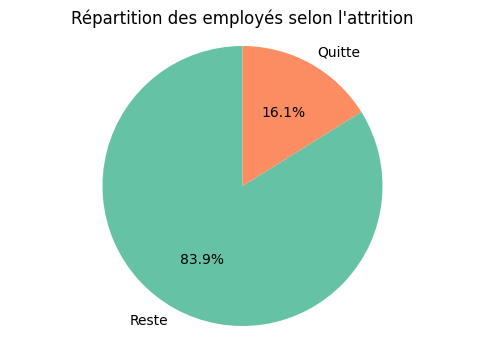

In [4]:
# Visualisation de la distribution de la variable "Attrition" avec un graphique en secteurs
attrition_counts = data['Attrition'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(attrition_counts, labels=['Reste', 'Quitte'], autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Répartition des employés selon l\'attrition')
plt.axis('equal')  # Pour faire un cercle parfait
plt.show()

<h2>Visualizing Numerical Features

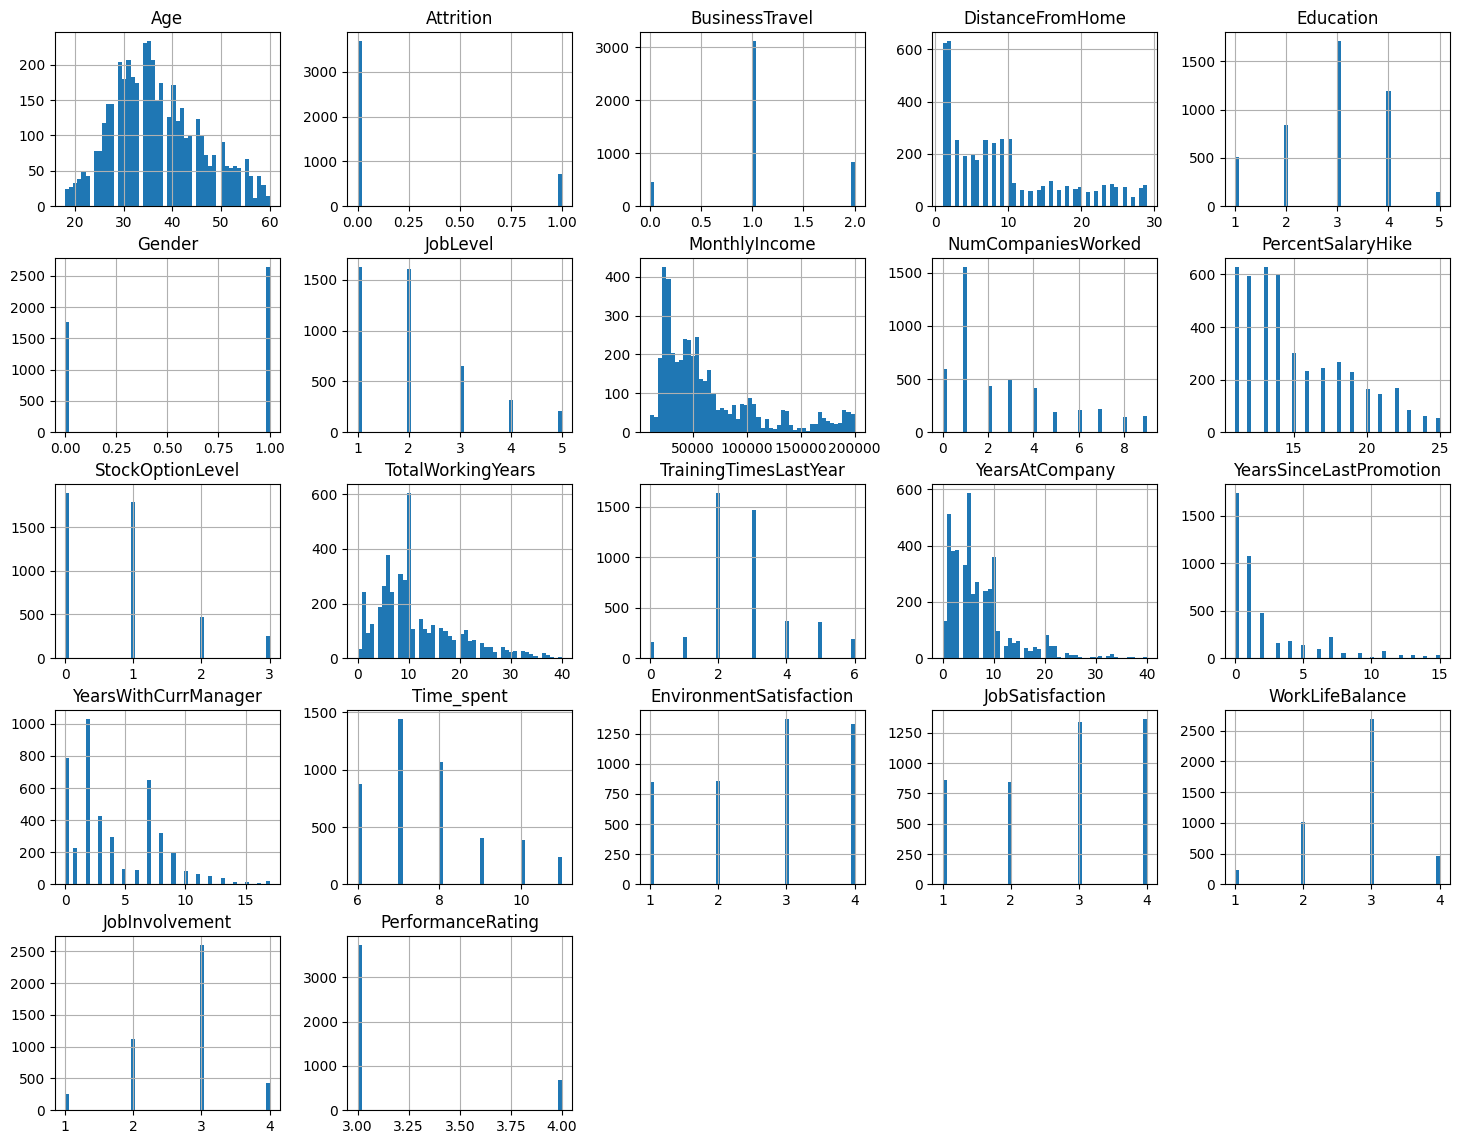

In [5]:
data_id= data.drop(columns=['EmployeeID'])
data_id.hist(bins=50, figsize=(18, 14))
plt.show()

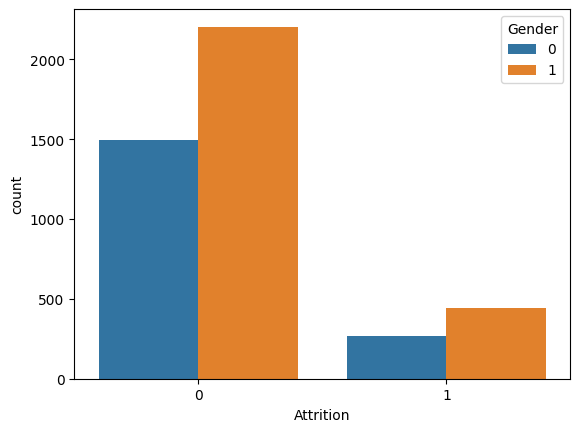

In [6]:
sns.countplot(x = "Attrition",data=data,hue="Gender")
plt.show()

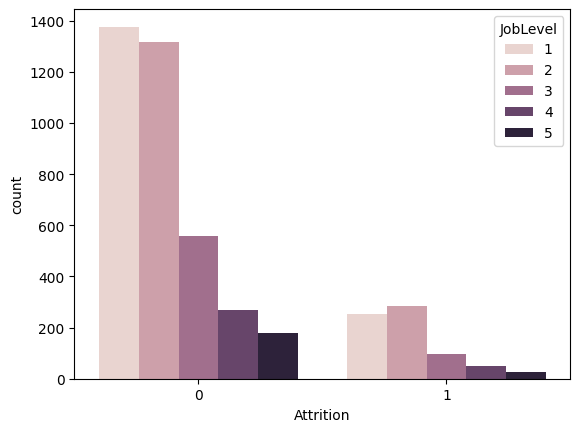

In [7]:
sns.countplot(x = "Attrition",data=data,hue="JobLevel")
plt.show()

In [8]:
#function to creat group of ages, this helps because we have 78 differente values here
def Age(dataframe):
    dataframe.loc[dataframe['Age'] <= 30,'Age'] = 1
    dataframe.loc[(dataframe['Age'] > 30) & (dataframe['Age'] <= 40), 'Age'] = 2
    dataframe.loc[(dataframe['Age'] > 40) & (dataframe['Age'] <= 50), 'Age'] = 3
    dataframe.loc[(dataframe['Age'] > 50) & (dataframe['Age'] <= 60), 'Age'] = 4
    return dataframe

Age(data);

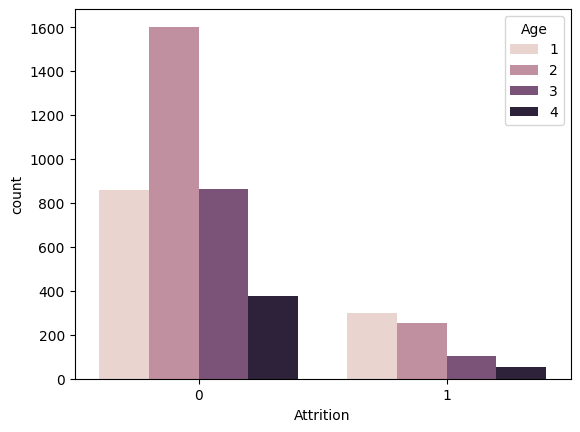

In [9]:
sns.countplot(x = "Attrition",data=data,hue="Age")
plt.show()

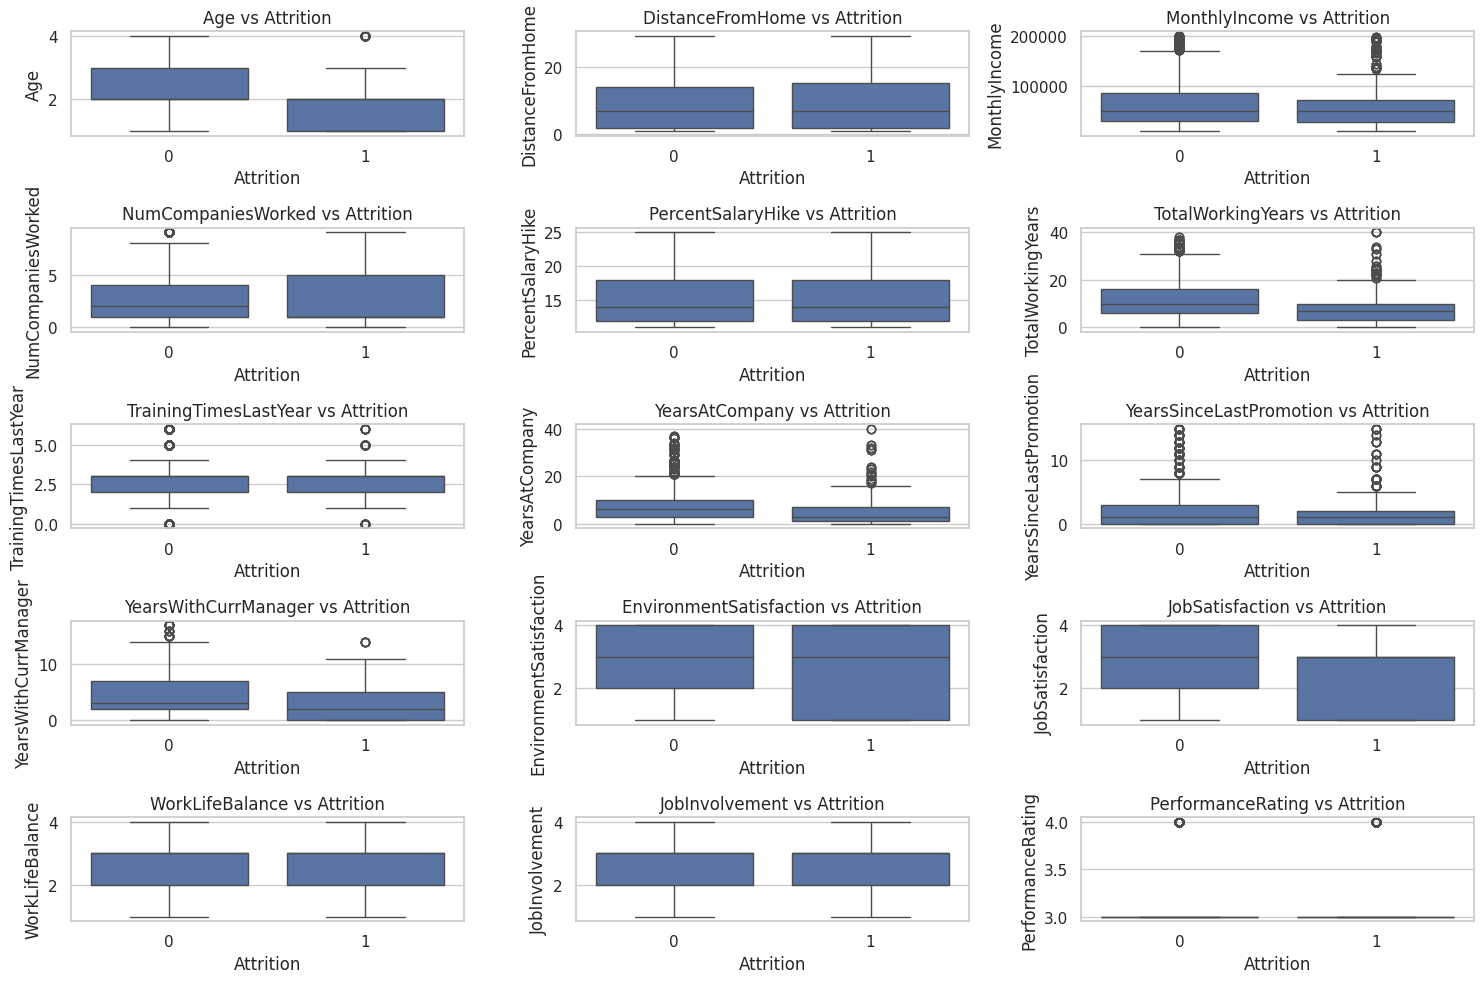

In [20]:
# Set the style of seaborn
sns.set(style='whitegrid')

# List of numerical features to visualize
numerical_features = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'PerformanceRating'
]

# Create box plots for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(5, 3, i + 1)  # Create a grid of plots
    sns.boxplot(x='Attrition', y=feature, data=data)
    plt.title(f'{feature} vs Attrition')
    plt.xlabel('Attrition')
    plt.ylabel(feature)

plt.tight_layout()  # Adjust the layout
plt.show()


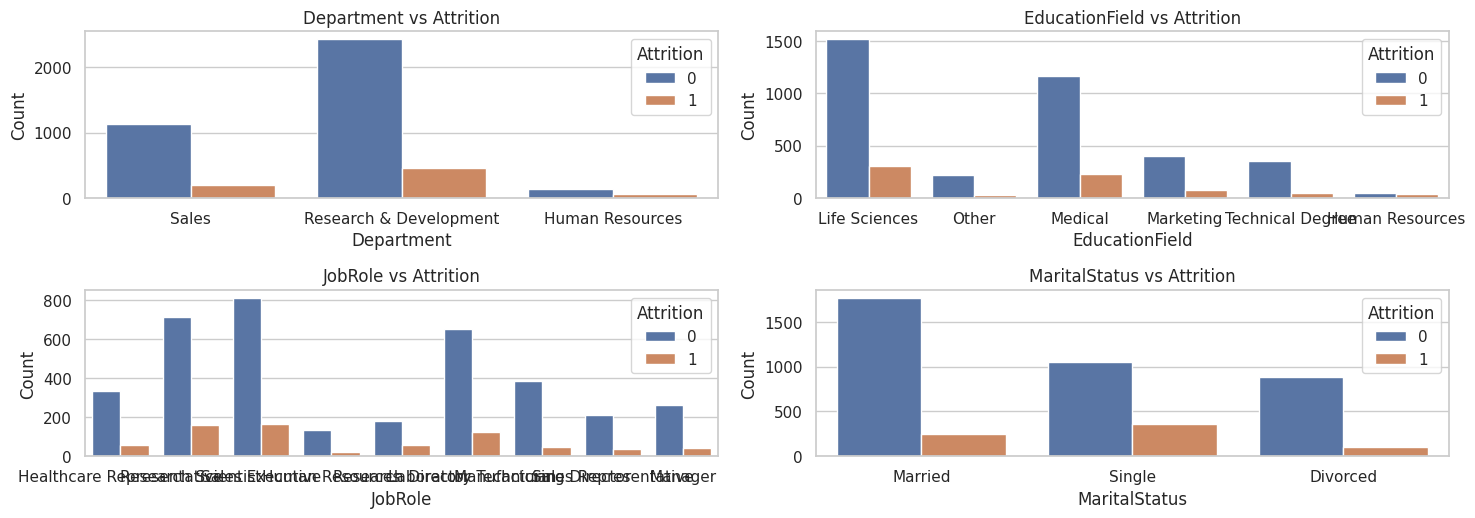

In [21]:

# List of categorical features to visualize (object type)
categorical_features = [
    'Department', 'EducationField', 'JobRole', 'MaritalStatus'
]

# Create count plots for categorical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(4, 2, i + 1)  # Create a grid of plots
    sns.countplot(x=feature, hue='Attrition', data=data)
    plt.title(f'{feature} vs Attrition')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()  # Adjust the layout
plt.show()

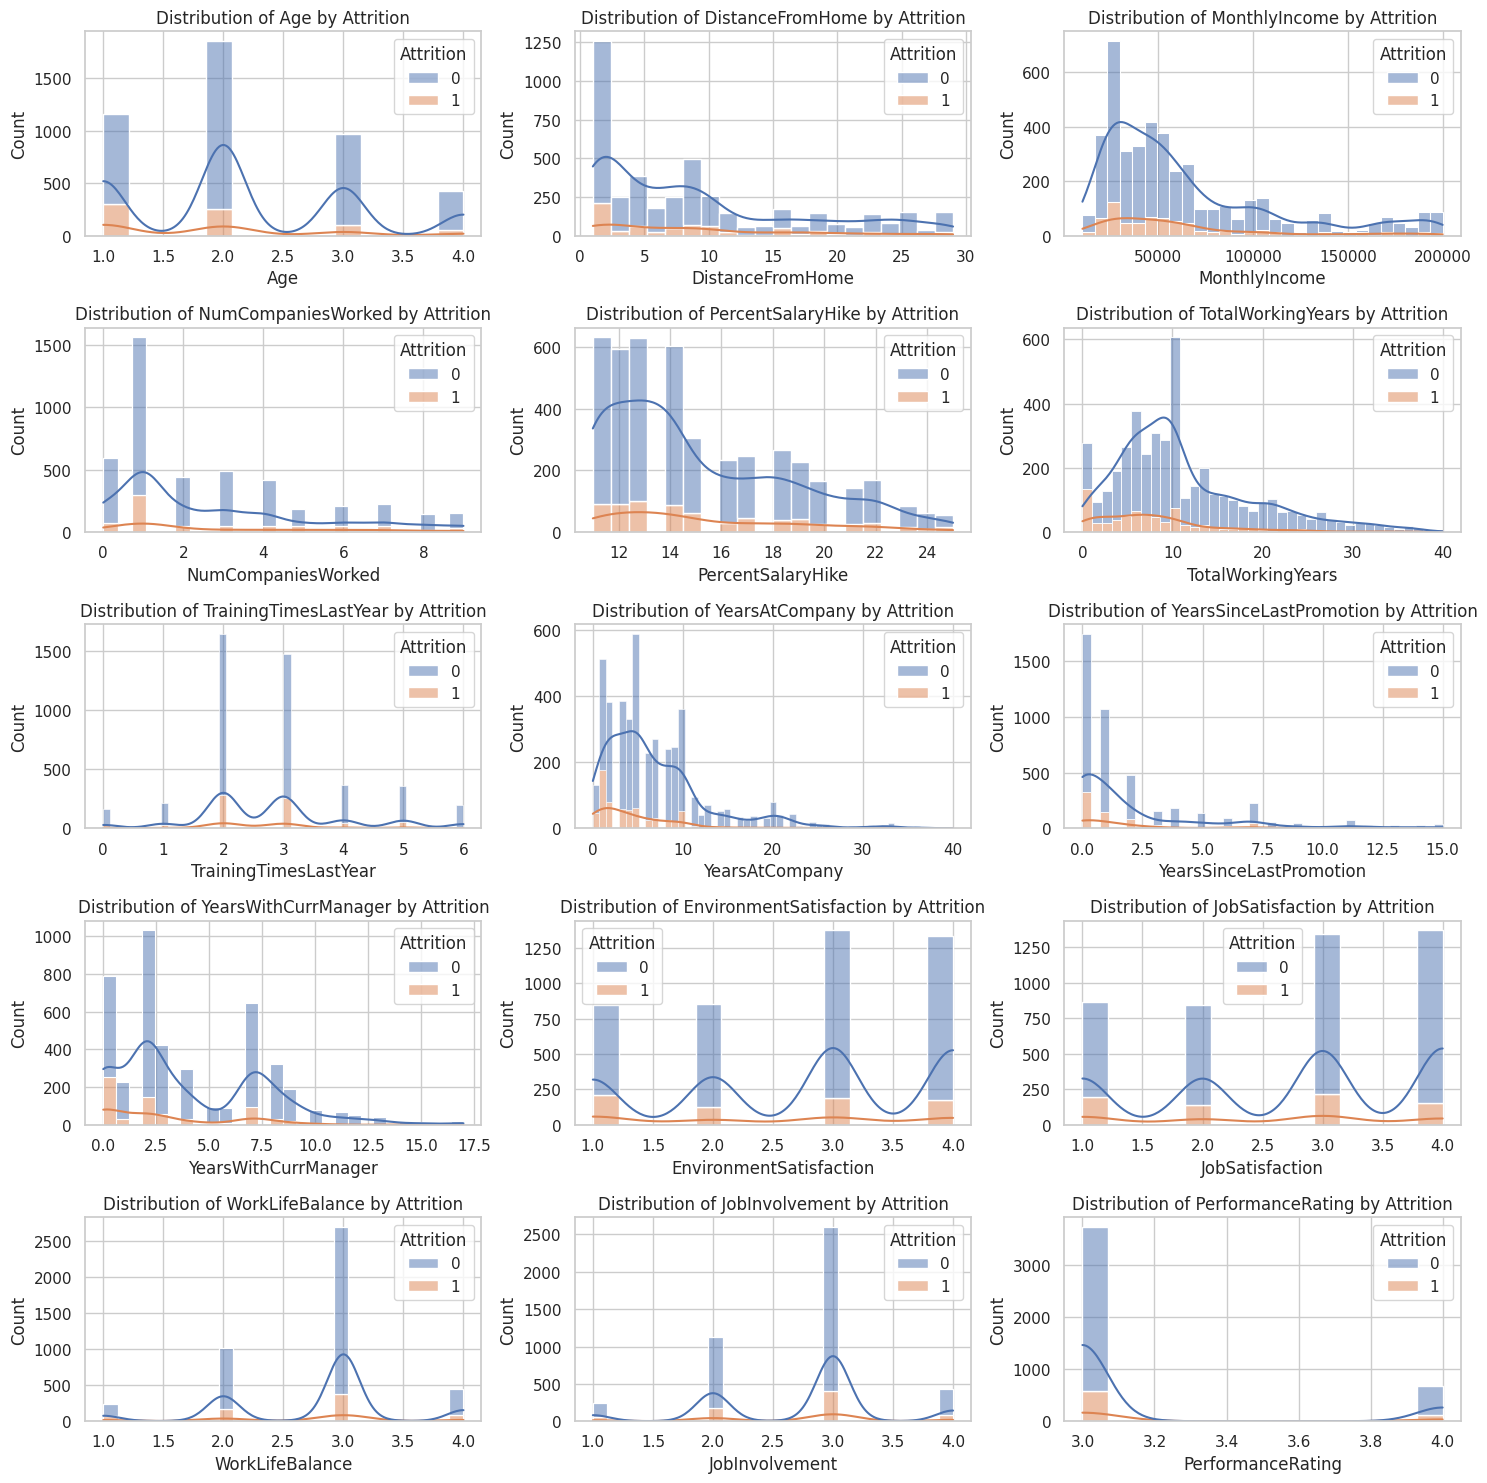

In [22]:


# List of numerical features
numerical_features = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'PerformanceRating'
]

# Create histograms or KDE plots for numerical features
plt.figure(figsize=(15, 15))
for i, feature in enumerate(numerical_features):
    plt.subplot(5, 3, i + 1)  # Create a grid of plots
    sns.histplot(data=data, x=feature, hue='Attrition', multiple='stack', kde=True)
    plt.title(f'Distribution of {feature} by Attrition')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()  # Adjust the layout
plt.show()

In [23]:
# Filter for employees who left (Attrition = 1)
attrition_data = data[data['Attrition'] == 1]

# Get descriptive statistics
attrition_summary = attrition_data.describe()
attrition_summary


,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,...,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Time_spent,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,711.000000,711.0,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,...,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000
mean,1.873418,1.0,1.240506,9.012658,2.877637,2191.767932,0.620253,2.037975,61682.616034,2.932489,...,2.654008,5.130802,1.945148,2.852321,8.309423,2.472574,2.471167,2.662447,2.704641,3.172996
std,0.924325,0.0,0.533225,7.772368,1.014233,1270.136654,0.485665,1.057485,44792.067695,2.673490,...,1.154834,5.941598,3.148633,3.138918,1.479402,1.163540,1.115296,0.814471,0.761739,0.378510
min,1.000000,1.0,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,10090.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,1.000000,1.0,1.000000,2.000000,2.000000,1072.000000,0.000000,1.000000,28440.000000,1.000000,...,2.000000,1.000000,0.000000,0.000000,7.000000,1.000000,1.000000,2.000000,2.000000,3.000000
50%,2.000000,1.0,1.000000,7.000000,3.000000,2165.000000,1.000000,2.000000,49080.000000,1.000000,...,3.000000,3.000000,1.000000,2.000000,8.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,1.0,2.000000,15.000000,4.000000,3341.000000,1.000000,2.000000,71040.000000,5.000000,...,3.000000,7.000000,2.000000,5.000000,10.000000,4.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,1.0,2.000000,29.000000,5.000000,4403.000000,1.000000,5.000000,198590.000000,9.000000,...,6.000000,40.000000,15.000000,14.000000,11.000000,4.000000,4.000000,4.000000,4.000000,4.000000


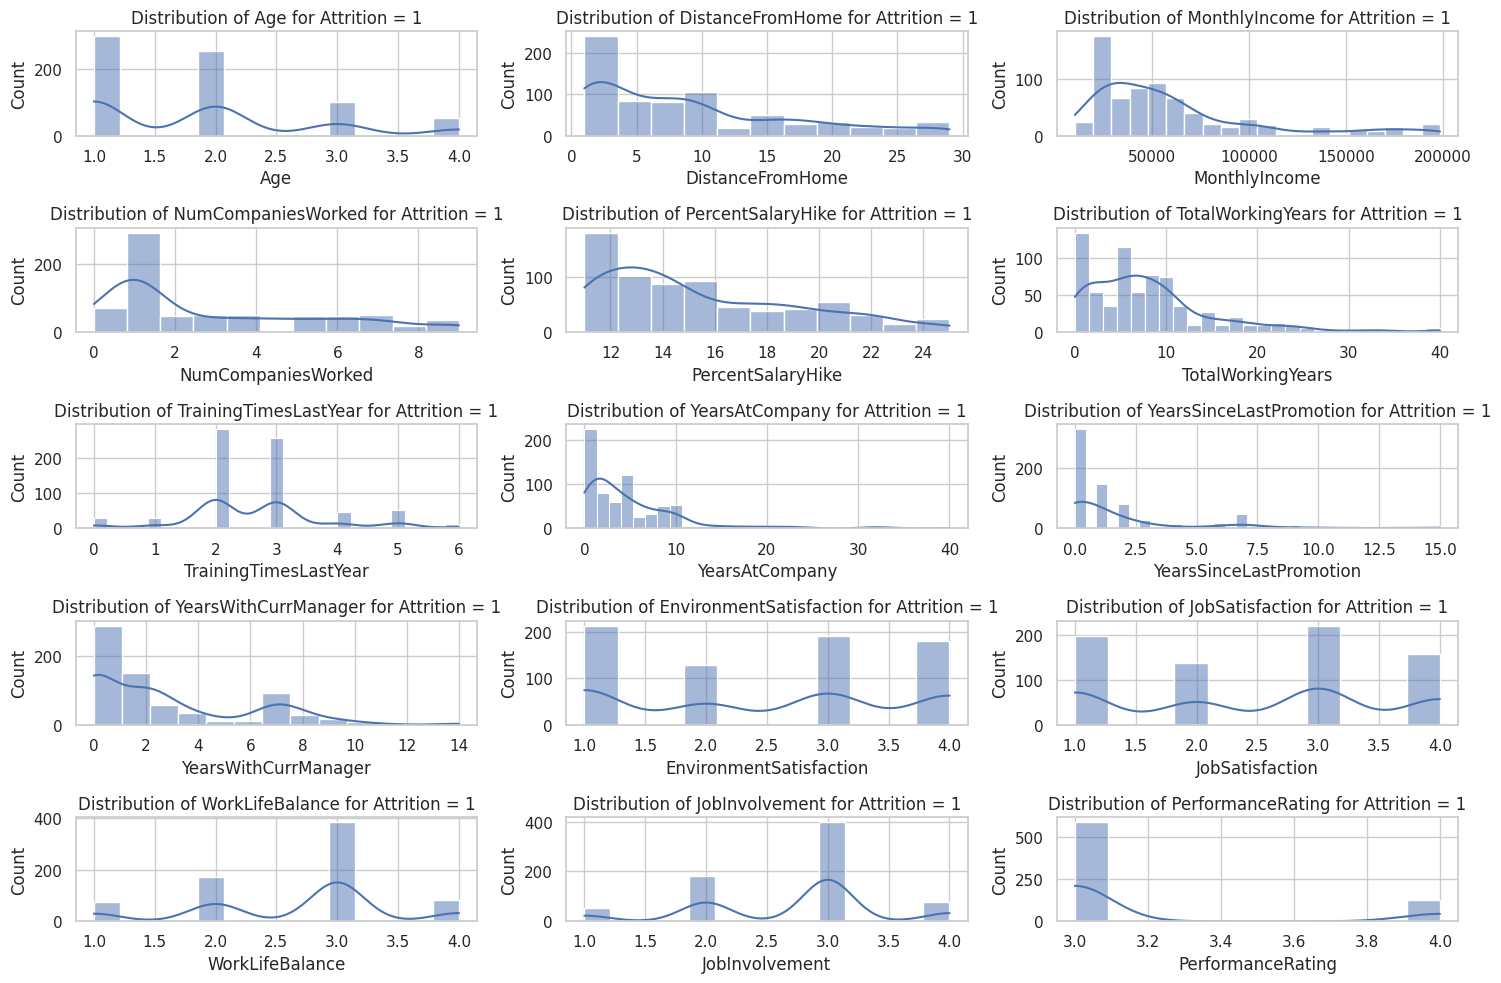

In [26]:
# Visualize numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(5, 3, i + 1)
    sns.histplot(data=attrition_data, x=feature, kde=True)
    plt.title(f'Distribution of {feature} for Attrition = 1')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Essai

## Goals for `likert_data`

### 1. Understanding Employee Satisfaction and Involvement
- **Objective:** To analyze employee engagement and satisfaction levels within the organization.
- **Variables Included:**
  - `JobInvolvement`: Measure of how involved employees feel in their work.
  - `JobLevel`: Hierarchical level of the employee within the organization.
  - `JobSatisfaction`: Overall satisfaction with the job role.
  - `EnvironmentSatisfaction`: Satisfaction with the work environment.
  - `WorkLifeBalance`: Balance between work and personal life.
  - `PerformanceRating`: Employee performance evaluation score.
  - `Attrition`: Indicator of whether an employee has left the organization.

### 2. Analyzing Trends and Correlations
- **Objective:** To identify trends and correlations between different aspects of job satisfaction and employee retention.
- **Use Cases:**
  - Understanding how job satisfaction impacts attrition rates.
  - Exploring the relationship between job involvement and performance ratings.
  - Identifying factors that contribute to a positive work environment.

### 3. Providing Insights for Management
- **Objective:** To provide actionable insights to management regarding employee engagement and satisfaction.
- **Outcome:** Use findings to develop strategies for improving employee retention and satisfaction.

---

## Goals for `ratio_data`

### 1. Quantifying Key Performance Indicators
- **Objective:** To create a dataset that quantifies various employee-related metrics for deeper analysis.
- **Variables Included:**
  - `Time_spent`: Total time spent working, which can indicate productivity.
  - `Age`: Age of the employee, which can correlate with experience and performance.
  - `DistanceFromHome`: Proximity to work, which may affect job satisfaction and attrition.
  - `MonthlyIncome`: Employee salary, relevant for financial satisfaction.
  - `NumCompaniesWorked`: Total number of companies an employee has worked for, which can indicate stability.
  - `PercentSalaryHike`: Percentage increase in salary, reflecting career growth.
  - `TotalWorkingYears`: Total years of experience, indicating the level of expertise.
  - `TrainingTimesLastYear`: Number of training sessions attended, relevant for professional development.
  - `YearsAtCompany`: Duration the employee has been with the company.
  - `YearsSinceLastPromotion`: Time since the last promotion, which can affect job satisfaction.
  - `YearsWithCurrManager`: Length of time working with the current manager, impacting relationship quality.

### 2. Conducting Comparative Analysis
- **Objective:** To facilitate comparative analysis across different employee demographics and performance metrics.
- **Use Cases:**
  - Evaluating how salary correlates with attrition and job satisfaction.
  - Analyzing how time spent at work affects productivity and performance ratings.
  - Understanding the impact of employee tenure on job involvement and satisfaction.

### 3. Supporting Data-Driven Decision Making
- **Objective:** To provide a quantitative basis for decision-making regarding HR policies and employee engagement initiatives.
- **Outcome:** Use data to identify areas needing improvement and develop targeted strategies for enhancing employee satisfaction and retention.


In [ ]:
# Define the ratio DataFrame with relevant features
ratio_data = data[['Time_spent', 'Age', 'DistanceFromHome', 'MonthlyIncome',
                   'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
                   'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
                   'YearsWithCurrManager', 'Attrition']]

# Define the Likert scale DataFrame
likert_data = data[['JobInvolvement', 'JobLevel', 'JobSatisfaction',
                    'EnvironmentSatisfaction', 'WorkLifeBalance',
                    'PerformanceRating', 'Attrition']]

In [ ]:
def logit_ratio(df):
    dict = {}
    for var in df.drop(columns = 'Attrition'):
        data = df[[var,'Attrition']].dropna()
        # get x, y
        x = data[var].values
        y = data['Attrition'].values
        # standardize
        x = (x - x.mean()) / (x.std())
        x = np.expand_dims(x,axis=-1)
        # fit the model
        model = LogisticRegression().fit(x,y)
        coeff = model.coef_
        coeff = np.squeeze(coeff,axis=1)
        dict[var] = coeff
        # gen result df
        res_df = pd.DataFrame(dict).T.rename(columns={0: "Coefficient"})
        res_df['Absolute_val'] = res_df.apply(lambda x: np.abs(x))
        res_df = res_df.sort_values('Absolute_val',ascending=False)
    return res_df

In [ ]:
display(
    "RATIO DATA COEFF", logit_ratio(ratio_data),
    "LIKERT - INTERVAL DATA COEFF", logit_ratio(likert_data)
)

'RATIO DATA COEFF'

,Coefficient,Absolute_val
TotalWorkingYears,-0.602791,0.602791
YearsWithCurrManager,-0.503502,0.503502
YearsAtCompany,-0.492813,0.492813
Time_spent,0.478887,0.478887
Age,-0.388272,0.388272
TrainingTimesLastYear,-0.138020,0.138020
NumCompaniesWorked,0.110338,0.110338
YearsSinceLastPromotion,-0.095650,0.095650
MonthlyIncome,-0.088247,0.088247
PercentSalaryHike,0.086348,0.086348


'LIKERT - INTERVAL DATA COEFF'

,Coefficient,Absolute_val
JobSatisfaction,-0.274927,0.274927
EnvironmentSatisfaction,-0.271184,0.271184
WorkLifeBalance,-0.166268,0.166268
PerformanceRating,0.061129,0.061129
JobInvolvement,-0.042026,0.042026
JobLevel,-0.028205,0.028205


In [ ]:
vis_df = pd.concat([logit_ratio(ratio_data),logit_ratio(likert_data)]).sort_values('Absolute_val',ascending=True) # concat to 1 df and sort

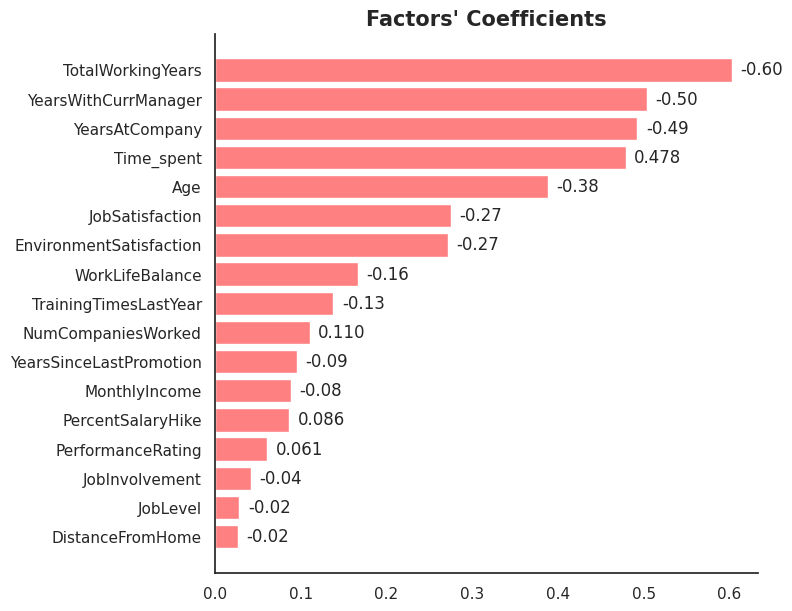

In [ ]:
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(7, 7))
cm = ['#FF8080'] * len(vis_df.index)
# Create a horizontal bar plot
ax.barh(
    y=vis_df.index,
    width=vis_df['Absolute_val'],
    color=cm
)

# Annotate each bar with the coefficient value
for var_name, var_val in vis_df.iterrows():
    ax.annotate(
        str(var_val['Coefficient'])[:5],
        xy=(var_val['Absolute_val'] + 0.01, var_name),
        va='center', ha='left', fontweight='medium'
    )

# Set the y-ticks and y-tick labels
ax.set_yticks(range(len(vis_df.index)))  # Set the tick positions
ax.set_yticklabels(vis_df.index, fontweight='medium')  # Set the tick labels

# Set title and labels
ax.set_title(
    "Factors' Coefficients",
    fontsize=15,
    fontweight='bold'
)

sns.despine()
plt.show()

<h2>Analysis of Factors Influencing Attrition

Based on the logistic regression results, we can draw several conclusions about the factors influencing attrition:

<h3> Negative Coefficients

These factors are associated with a lower likelihood of attrition:
- **Total Working Years (-0.60)**: Employees with more total working years are less likely to leave.
- **Years With Current Manager (-0.50)**: Longer tenure with the current manager reduces the likelihood of attrition.
- **Years At Company (-0.49)**: Employees who have been with the company longer are less likely to leave.
- **Age (-0.38)**: Older employees are less likely to leave.
- **Environment Satisfaction (-0.27)** and **Job Satisfaction (-0.27)**: Higher satisfaction in these areas reduces attrition.
- **Work-Life Balance (-0.16)**: Better work-life balance is associated with lower attrition.
- **Training Times Last Year (-0.13)**: More training sessions correlate with lower attrition.
- **Years Since Last Promotion (-0.09)**: More time since the last promotion slightly reduces attrition.
- **Monthly Income (-0.08)**: Higher income slightly reduces attrition.
- **Job Involvement (-0.04)** and **Job Level (-0.02)**: Higher involvement and job level slightly reduce attrition.
- **Distance From Home (-0.02)**: Closer proximity to home slightly reduces attrition.

<h3> Positive Coefficients

These factors are associated with a higher likelihood of attrition:
- **Time Spent (0.478)**: More time spent at work increases the likelihood of attrition.
- **Num Companies Worked (0.110)**: Employees who have worked at more companies are more likely to leave.
- **Percent Salary Hike (0.086)**: Higher salary hikes are associated with a slight increase in attrition.
- **Performance Rating (0.061)**: Higher performance ratings are slightly associated with increased attrition.

<h3>Key Insights

- **Tenure and Experience**: Longer tenure with the company and manager, as well as more total working years, significantly reduce attrition.
This result indicates that the longer employees stick to this firm, the less likely they are fired or leaving the company on themselves.
- **Satisfaction and Balance**: Job and environment satisfaction, along with work-life balance, are crucial in retaining employees.
- **Training and Promotion**: Regular training and timely promotions help in reducing attrition.
- **Income and Proximity**: Higher income and shorter commutes also contribute to lower attrition, though their impact is smaller.
> </ol> Next step: We will continue evaluating these relationships using feature importance extracted from decision tree.


